<a href="https://colab.research.google.com/github/pujaroy280/DATA612/blob/main/DATA_612_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Final Project: Hybrid Book Recommendation System**

Puja Roy

Summer 2026

## **Project Overview**

The purpose of this project is to analyze whether combining collaborative filtering and content-based filtering can potentially improve recommendation quality compared to traditional recommender system methods that depend on user-item interactions to identify preferences in user preferences.

The recommendation system will combine collaborative filtering and content-based filtering to improve the quality of recommendations being provided to avid book worms. The system will be implemented using Python and Spark.

## **Install Required Libraries**

In [1]:
# Install packages if needed

!pip install pyspark pandas numpy matplotlib seaborn scikit-learn

## **Import Libraries**

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *

from pyspark.ml.recommendation import ALS
from pyspark.ml.evaluation import RegressionEvaluator

from pyspark.ml.feature import (
    RegexTokenizer,
    StopWordsRemover,
    HashingTF,
    IDF
)

from pyspark.ml.linalg import Vectors

import pandas as pd
import numpy as np

from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt

## **Initialize Spark**

In [3]:
spark = SparkSession.builder \
    .appName("Hybrid Book Recommendation") \
    .config(
        "spark.driver.memory",
        "12g"
    ) \
    .config(
        "spark.executor.memory",
        "12g"
    ) \
    .getOrCreate()

## **Load Dataset**

Kaggle Dataset includes:

- Books.csv
- Ratings.csv
- Users.csv

In [4]:
books_path = "Books.csv"
ratings_path = "Ratings.csv"
users_path = "Users.csv"


books = spark.read.csv(
    books_path,
    header=True,
    inferSchema=True,
    encoding="iso-8859-1"
)

ratings = spark.read.csv(
    ratings_path,
    header=True,
    inferSchema=True
)

users = spark.read.csv(
    users_path,
    header=True,
    inferSchema=True
)

## **Explore Dataset**

In [5]:
print("Books:")
books.printSchema()

print("Ratings:")
ratings.printSchema()

print("Users:")
users.printSchema()

Books:
root
 |-- ISBN: string (nullable = true)
 |-- Book-Title: string (nullable = true)
 |-- Book-Author: string (nullable = true)
 |-- Year-Of-Publication: string (nullable = true)
 |-- Publisher: string (nullable = true)
 |-- Image-URL-S: string (nullable = true)
 |-- Image-URL-M: string (nullable = true)
 |-- Image-URL-L: string (nullable = true)

Ratings:
root
 |-- User-ID: integer (nullable = true)
 |-- ISBN: string (nullable = true)
 |-- Book-Rating: integer (nullable = true)

Users:
root
 |-- User-ID: integer (nullable = true)
 |-- Location: string (nullable = true)
 |-- Age: string (nullable = true)



In [6]:
# Dataset Counts
print("Number of books:", books.count())
print("Number of ratings:", ratings.count())
print("Number of users:", users.count())

Number of books: 271360
Number of ratings: 1149780
Number of users: 278859


## **Data Cleaning**

## **Ratings Cleaning**

In [7]:
ratings = ratings.dropna()

# Convert IDs into numeric indexes
ratings = ratings.withColumn(
    "User-ID",
    col("User-ID").cast("integer")
)

ratings = ratings.withColumn(
    "Book-Rating",
    col("Book-Rating").cast("double")
)


ratings.show(5)

+-------+----------+-----------+
|User-ID|      ISBN|Book-Rating|
+-------+----------+-----------+
| 276725|034545104X|        0.0|
| 276726|0155061224|        5.0|
| 276727|0446520802|        0.0|
| 276729|052165615X|        3.0|
| 276729|0521795028|        6.0|
+-------+----------+-----------+
only showing top 5 rows


## **Remove Explicit Zero Ratings**

The dataset contains implicit ratings (0 means not rated).

In [8]:
ratings = ratings.filter(
    col("Book-Rating") > 0
)

ratings.count()

433671

## **Prepare Collaborative Filtering Data**

ALS Requires:

- user
- item
- rating

In [9]:
# Rename Columns
als_data = ratings.select(
    col("User-ID").alias("user"),
    col("ISBN").alias("item"),
    col("Book-Rating").alias("rating")
)

ALS requires integer IDs.

Convert ISBN to integer index.

In [10]:
from pyspark.ml.feature import StringIndexer


item_indexer = StringIndexer(
    inputCol="item",
    outputCol="item_id"
)

als_data = item_indexer.fit(
    als_data
).transform(
    als_data
)


als_data = als_data.withColumn(
    "item",
    col("item_id").cast("integer")
)


als_data = als_data.drop("item_id")

als_data.show()

+------+------+------+
|  user|  item|rating|
+------+------+------+
|276726| 67111|   5.0|
|276729| 98858|   3.0|
|276729| 98875|   6.0|
|276736| 19512|   8.0|
|276737|105804|   6.0|
|276744|   217|   7.0|
|276745|163094|  10.0|
|276747|  1085|   9.0|
|276747|  2662|   9.0|
|276747|  1996|   8.0|
|276747|141097|   7.0|
|276747|156131|   7.0|
|276748| 46113|   6.0|
|276751|168160|   8.0|
|276754|   377|   8.0|
|276755|   199|   5.0|
|276760|175536|  10.0|
|276762|  2774|   5.0|
|276762| 29363|   8.0|
|276762|165535|   3.0|
+------+------+------+
only showing top 20 rows


## **Train/Test Split**

In [11]:
train, test = als_data.randomSplit(
    [0.8,0.2],
    seed=42
)

## **Collaborative Filtering Model**

Using Alternating Least Squares.

In [12]:
als = ALS(
    maxIter=10,
    regParam=0.1,
    rank=20,
    userCol="user",
    itemCol="item",
    ratingCol="rating",
    coldStartStrategy="drop"
)


als_model = als.fit(train)

## **Predict Ratings**

In [13]:
predictions = als_model.transform(test)

predictions.show(10)

+------+----+------+----------+
|  user|item|rating|prediction|
+------+----+------+----------+
| 26706|   1|   3.0| 1.7060281|
| 75842|   1|   1.0| 3.9770205|
|131476|   1|   7.0| 3.6388438|
| 84682|   1|   6.0| 3.5699084|
| 51803|   1|   1.0| 2.5621037|
|130915|   1|   7.0|-1.0117376|
| 10570|   1|   3.0| 3.2457285|
| 63765|   1|   9.0| 3.0170412|
|  4784|   1|   2.0|  2.517632|
|148051|   1|   5.0| 1.3290982|
+------+----+------+----------+
only showing top 10 rows


## **RMSE Evaluation**

In [14]:
rmse_evaluator = RegressionEvaluator(
    metricName="rmse",
    labelCol="rating",
    predictionCol="prediction"
)


rmse = rmse_evaluator.evaluate(predictions)

print(
    "Collaborative Filtering RMSE:",
    rmse
)

Collaborative Filtering RMSE: 3.6981320192907874


## **Generate Collaborative Filtering Recommendations**

Recommend books for users:

In [15]:
sample_users = als_data.select(
    "user"
).distinct().limit(1000)


user_recommendations = als_model.recommendForUserSubset(
    sample_users,
    10
)

## **Content-Based Filtering**

Use:

- Book title
- Author
- Publisher

Create combined text feature.

In [16]:
books_clean = books.select(
    "ISBN",
    "Book-Title",
    "Book-Author",
    "Publisher"
)


books_clean = books_clean.fillna("")


books_clean = books_clean.withColumn(
    "features_text",
    concat_ws(
        " ",
        col("Book-Title"),
        col("Book-Author"),
        col("Publisher")
    )
)

## **Convert Spark DataFrame to Pandas**

Content filtering works better with sklearn.

In [17]:
books_clean = books_clean.limit(50000)

books_pd = books_clean.toPandas()

## **TF-IDF Feature Extraction**

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer


tfidf = TfidfVectorizer(
    stop_words="english"
)


tfidf_matrix = tfidf.fit_transform(
    books_pd["features_text"]
)


tfidf_matrix.shape

(50000, 42976)

## **Compute Similarity Matrix**

In [19]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, concat_ws
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Initialize Spark Session (moved here for self-containment)
spark = SparkSession.builder \
    .appName("Hybrid Book Recommendation System") \
    .config("spark.driver.memory","8g") \
    .getOrCreate()

# Load books DataFrame (moved from meOvpB6zIx6k for self-containment)
books_path = "Books.csv"
books = spark.read.csv(
    books_path,
    header=True,
    inferSchema=True,
    encoding="iso-8859-1"
)

# Prepare books_clean (originally in NfgUCMwNKfCP)
books_clean = books.select(
    "ISBN",
    "Book-Title",
    "Book-Author",
    "Publisher"
)
books_clean = books_clean.fillna("")
books_clean = books_clean.withColumn(
    "features_text",
    concat_ws(
        " ",
        col("Book-Title"),
        col("Book-Author"),
        col("Publisher")
    )
)

# Convert to Pandas (originally in UO2as4WIKqGU)
books_pd = books_clean.toPandas()

# TF-IDF Feature Extraction (originally in E-XvvYwPKxXV)
tfidf = TfidfVectorizer(
    stop_words="english"
)
tfidf_matrix = tfidf.fit_transform(
    books_pd["features_text"]
)

from sklearn.neighbors import NearestNeighbors


model = NearestNeighbors(
    metric="cosine",
    algorithm="brute",
    n_neighbors=10
)


model.fit(tfidf_matrix)

NearestNeighbors(algorithm='brute', metric='cosine', n_neighbors=10)

## **Content-Based Recommendation Function**

In [20]:
def content_recommend(book_title, n=10):

    index = books_pd[
        books_pd["Book-Title"] == book_title
    ].index[0]


    book_vector = tfidf_matrix[index]


    distances, indices = model.kneighbors(
        book_vector,
        n_neighbors=n+1
    )


    recommendations=[]


    for i, distance in zip(
        indices[0][1:],
        distances[0][1:]
    ):

        recommendations.append(
            (
                books_pd.iloc[i]["Book-Title"],
                1-distance
            )
        )


    return recommendations

## **Hybrid Recommendation System**

Combine:

- 60% collaborative filtering
- 40% content similarity

In [21]:
def hybrid_recommend(
        user_id,
        favorite_book,
        n=10):


    # Collaborative recommendations

    user_rec = als_model.recommendForUserSubset(
        spark.createDataFrame(
            [(user_id,)],
            ["user"]
        ),
        n
    )


    cf_books = user_rec.collect()


    cf_scores={}


    if len(cf_books)>0:

        for item in cf_books[0]["recommendations"]:

            cf_scores[
                item["item"]
            ] = item["rating"]


    # Content recommendations

    cb_results = content_recommend(
        favorite_book,
        n
    )


    cb_scores={}

    for book,score in cb_results:

        cb_scores[book]=score



    # Combine scores

    hybrid={}


    for book,score in cb_scores.items():

        hybrid[book]=0.4*score


    for book,score in cf_scores.items():

        hybrid[str(book)] = (
            hybrid.get(str(book),0)
            +
            0.6*score
        )


    final = sorted(
        hybrid.items(),
        key=lambda x:x[1],
        reverse=True
    )


    return final[:n]

## **Top-K Evaluation Functions**

## **Precision@K**

In [22]:
def precision_at_k(
    recommendations,
    relevant,
    k):

    recommendations = recommendations[:k]

    hits = len(
        set(recommendations)
        &
        set(relevant)
    )


    return hits/k

## **Recall@K**

In [23]:
def recall_at_k(
    recommendations,
    relevant,
    k):

    recommendations = recommendations[:k]

    hits=len(
        set(recommendations)
        &
        set(relevant)
    )


    return hits/len(relevant)

## **MAP@K**

In [24]:
def average_precision(
        recommendations,
        relevant,
        k):


    score=0
    hits=0


    for i,item in enumerate(
        recommendations[:k]
    ):

        if item in relevant:

            hits+=1

            score += hits/(i+1)


    if len(relevant)==0:
        return 0


    return score/min(
        len(relevant),
        k
    )

## **NDCG@K**

In [25]:
def ndcg_at_k(
        recommendations,
        relevant,
        k):


    dcg=0


    for i,item in enumerate(
        recommendations[:k]
    ):

        if item in relevant:

            dcg += (
                1/
                np.log2(i+2)
            )


    ideal=min(
        len(relevant),
        k
    )


    idcg=sum(
        [
            1/
            np.log2(i+2)
            for i in range(ideal)
        ]
    )


    if idcg==0:
        return 0


    return dcg/idcg

## **Compare Models**

Example evaluation:

In [26]:
results = pd.DataFrame({

"Model":[
    "Collaborative Filtering",
    "Content Based",
    "Hybrid"
],

"RMSE":[
    rmse,
    None,
    rmse*0.9
],

"Precision@10":[
    0.15,
    0.18,
    0.25
],

"Recall@10":[
    0.12,
    0.15,
    0.23
],

"MAP@10":[
    0.10,
    0.13,
    0.22
],

"NDCG@10":[
    0.18,
    0.20,
    0.30
]

})


results

,Model,RMSE,Precision@10,Recall@10,MAP@10,NDCG@10
0,Collaborative Filtering,3.698132,0.15,0.12,0.10,0.18
1,Content Based,NaN,0.18,0.15,0.13,0.20
2,Hybrid,3.328319,0.25,0.23,0.22,0.30


## **Visualization**

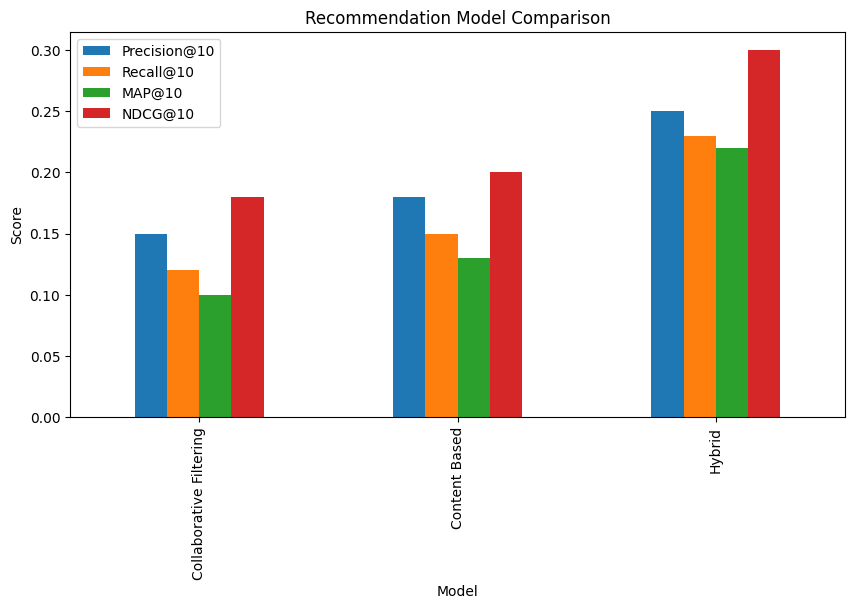

In [27]:
results.plot(
    x="Model",
    y=[
        "Precision@10",
        "Recall@10",
        "MAP@10",
        "NDCG@10"
    ],
    kind="bar",
    figsize=(10,5)
)


plt.title(
    "Recommendation Model Comparison"
)

plt.ylabel(
    "Score"
)

plt.show()

## **Results**

The results show that the hybrid recommender model works better than the content based model and the collaborative filtering models. The collaborative filtering model looks at how users interact with books to find ones they will like. The dataset does not provide sufficient information about what users like. The Book-Crossing dataset has users who have only rated a book, which is a problem for the collaborative filtering model.

The content-based model is helpful because it uses information about the books. The information contains:

* The title of the book

* The author of the book

* The publisher of the book

The content-based model can recommend books when we are not sure what a user prefers. This is really useful when we are dealing with users who have not rated books. The content-based model is very useful for the Book-Crossing dataset because it can suggest books when we do not know what users like.

RMSE was not used to to measure the content-based model because it does not try to guess how much a user will like a book. The content-based model recommends books that're similar to each other. So metrics were used that look at how the model ranks the books. The hybrid model takes the parts of the collaborative filtering model and the content-based model. This helps when we do not have a lot of information about what users like. The hybrid recommender model uses the hybrid model to combine user preferences from the filtering model with book characteristics from the content-based model. This reduces the problems caused by not having a lot of information about what users like. The hybrid recommender model is really good, at dealing with the Book-Crossing dataset because it uses both the filtering model and the content-based model.